In [1]:
from tqdm import tqdm
from pathlib import Path

import os
import sys
import colorsys
import matplotlib.pyplot as plt

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

# **Tiny-Imagenet200**
The dataset contains 200 classes divided uniformly by class.

# **CIFAR-10**

In [2]:
from computer_vision.dataset import prepare_cifar10

train, validation, weights, num_classes, categories, dataset_name, dataset_type = prepare_cifar10(datasets_path, delete=False)

100%|██████████| 8/8 [00:00<00:00, 22.81it/s]


# **PASCALVOC2007**

In [3]:
from computer_vision.dataset import prepare_vocdetection

train, validation, weights, num_classes, categories, dataset_name, dataset_type = prepare_vocdetection(datasets_path, "2007", box_format="xywh")

In [4]:
colors = [colorsys.hsv_to_rgb(i / num_classes, 0.8, 0.8) for i in range(num_classes)]

In [5]:
from computer_vision.metrics import intersection_over_union

import torch
elements_per_class_trainset = [0] * num_classes
bboxes_overlay_trainset = []

for (_, bboxes), (_, labels) in tqdm(zip(train["bboxes"].items(), train["labels"].items()), total=len(train["bboxes"]), leave=True):
    for label in labels:
        elements_per_class_trainset[label] += 1

    if len(bboxes) > 1:
        for i in range(len(bboxes) - 1):
            for j in range(i+1, len(bboxes) - 1):
                bboxes_overlay_trainset.append(intersection_over_union(torch.tensor(bboxes[i]), torch.tensor(bboxes[j]), box_format="xywh").item())

elements_per_class_validationset = [0] * num_classes
bboxes_overlay_validationset = []

for (_, bboxes), (_, labels) in tqdm(zip(validation["bboxes"].items(), validation["labels"].items()), total=len(validation["bboxes"]), leave=True):
    for label in labels:
        elements_per_class_validationset[label] += 1

    if len(bboxes) > 1:
        for i in range(len(bboxes) - 1):
            for j in range(i+1, len(bboxes) - 1):
                bboxes_overlay_validationset.append(intersection_over_union(torch.tensor(bboxes[i]), torch.tensor(bboxes[j]), box_format="xywh"))

100%|██████████| 2510/2510 [00:01<00:00, 2086.31it/s]


**Classes Distribution**

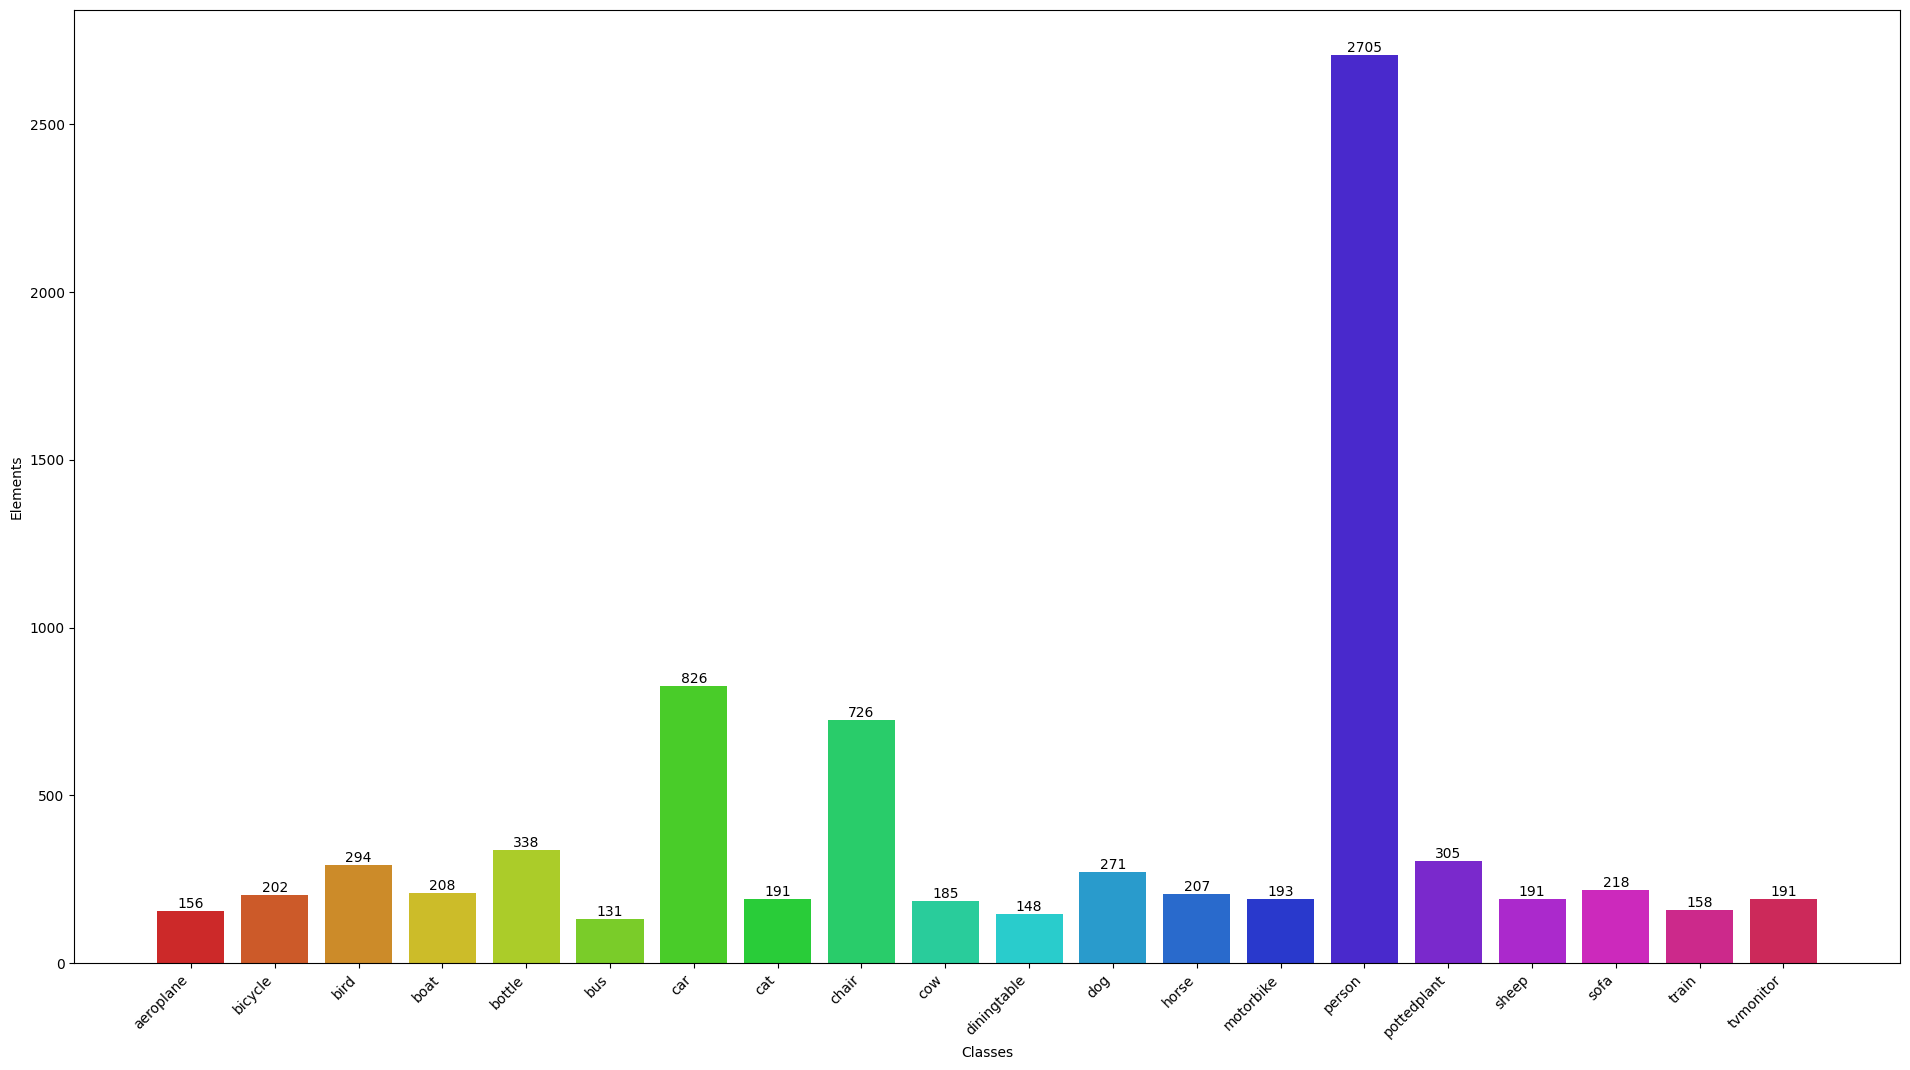

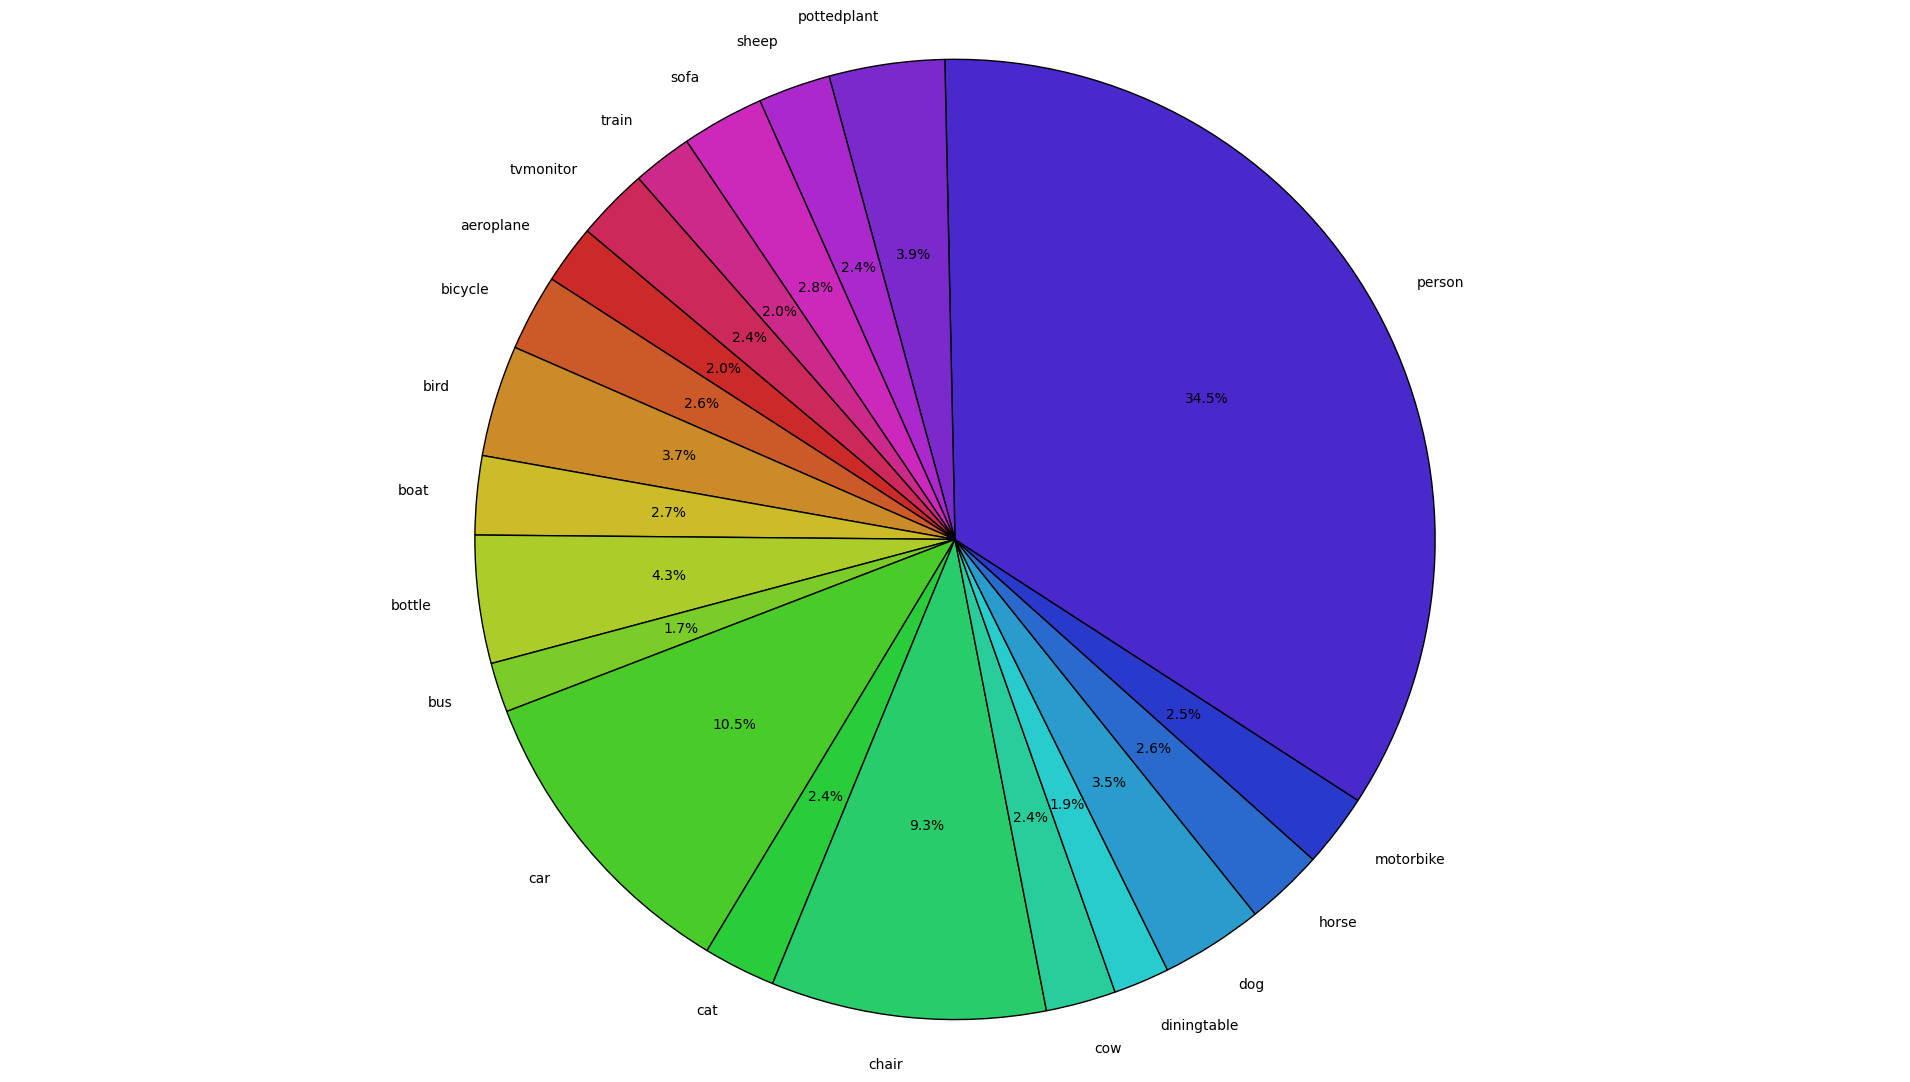

In [6]:
plt.figure(figsize=(19.2, 10.8))
barplot = plt.bar(range(len(categories)), elements_per_class_trainset, color=colors)
plt.bar_label(barplot, elements_per_class_trainset)
plt.xlabel('Classes')
plt.ylabel('Elements')
plt.xticks(range(len(categories)), categories, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_classes_distribution"), pad_inches=0.)
plt.show()

plt.figure(figsize=(19.2, 10.8))
plt.pie(elements_per_class_trainset, labels=categories.keys(), autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_pie_classes_distribution"), pad_inches=0.)
plt.show()

# **PASCALVOC2012**

In [7]:
from computer_vision.dataset import prepare_vocdetection

train, validation, weights, num_classes, categories, dataset_name, dataset_type = prepare_vocdetection(datasets_path, "2012", box_format="xywh")

100%|██████████| 17125/17125 [00:03<00:00, 5317.82it/s]


In [8]:
colors = [colorsys.hsv_to_rgb(i / num_classes, 0.8, 0.8) for i in range(num_classes)]

In [9]:
from computer_vision.metrics import intersection_over_union

import torch
elements_per_class_trainset = [0] * num_classes
bboxes_overlay_trainset = []

for (_, bboxes), (_, labels) in tqdm(zip(train["bboxes"].items(), train["labels"].items()), total=len(train["bboxes"]), leave=True):
    for label in labels:
        elements_per_class_trainset[label] += 1

    if len(bboxes) > 1:
        for i in range(len(bboxes) - 1):
            for j in range(i+1, len(bboxes) - 1):
                bboxes_overlay_trainset.append(intersection_over_union(torch.tensor(bboxes[i]), torch.tensor(bboxes[j]), box_format="xywh").item())

100%|██████████| 4323/4323 [00:02<00:00, 1776.52it/s]


**Classes Distribution**

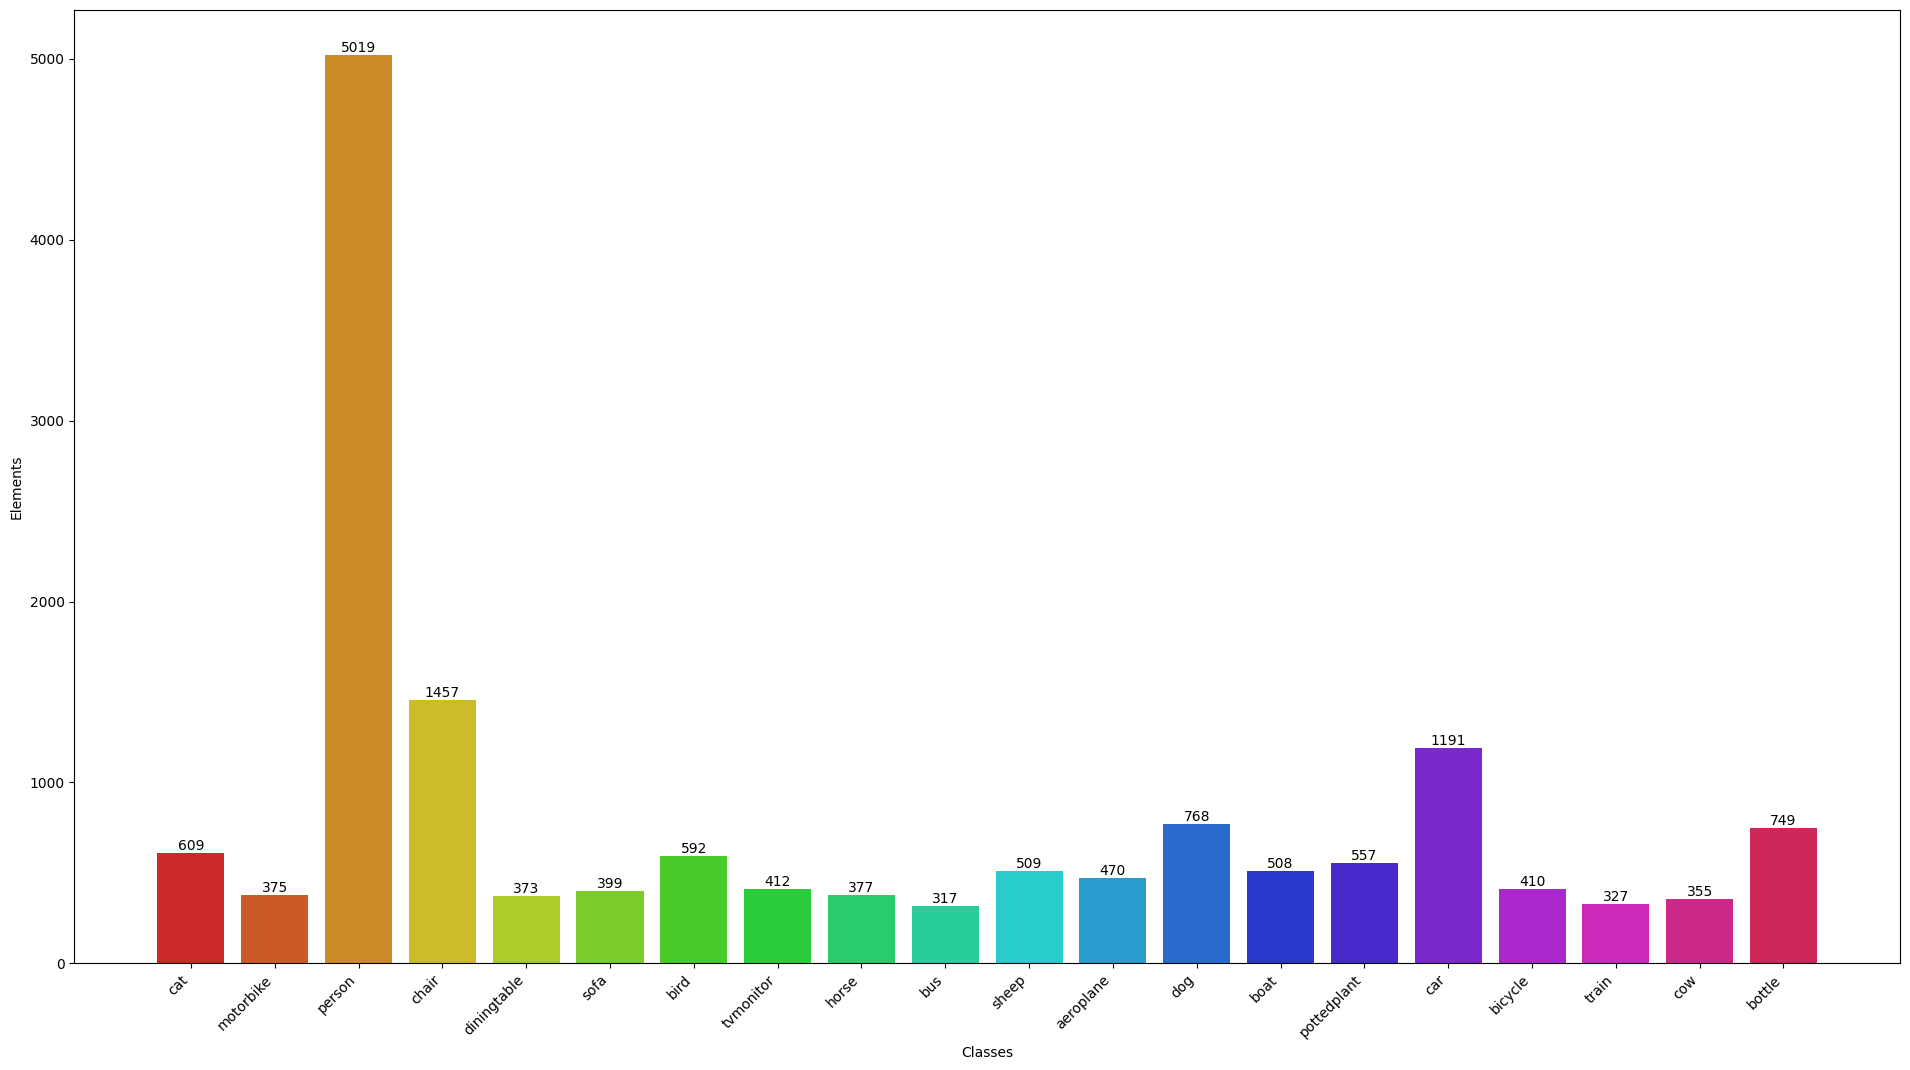

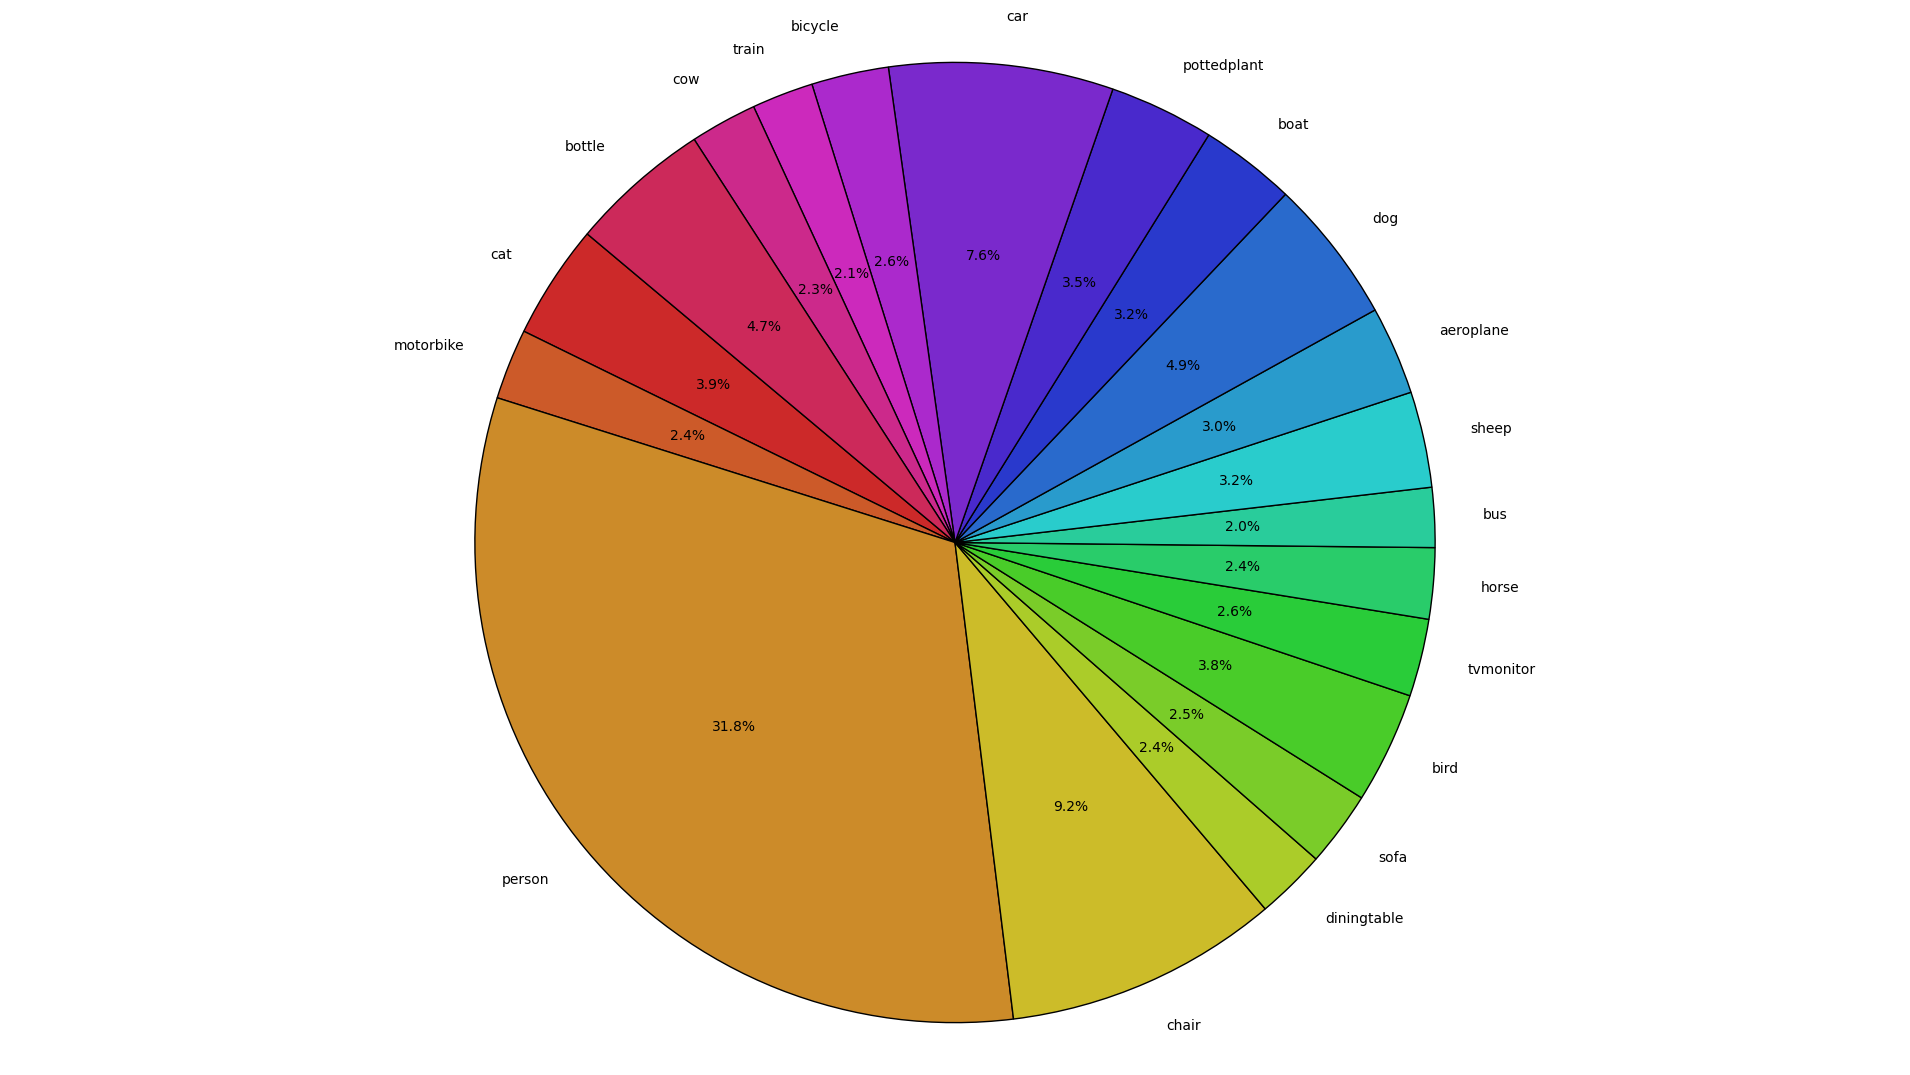

In [10]:
plt.figure(figsize=(19.2, 10.8))
barplot = plt.bar(range(len(categories)), elements_per_class_trainset, color=colors)
plt.bar_label(barplot, elements_per_class_trainset)
plt.xlabel('Classes')
plt.ylabel('Elements')
plt.xticks(range(len(categories)), categories, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_classes_distribution"), pad_inches=0.)
plt.show()

plt.figure(figsize=(19.2, 10.8))
plt.pie(elements_per_class_trainset, labels=categories.keys(), autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_pie_classes_distribution"), pad_inches=0.)
plt.show()

# **COCO2017**

In [11]:
from computer_vision.dataset import prepare_coco2017

train, validation, weights, num_classes, categories, dataset_name, dataset_type = prepare_coco2017(datasets_path, size=32, box_format="xywh")

100%|██████████| 36781/36781 [00:15<00:00, 2344.91it/s]


In [12]:
colors = [colorsys.hsv_to_rgb(i / num_classes, 0.8, 0.8) for i in range(num_classes)]

In [13]:
from computer_vision.metrics import intersection_over_union

import torch
elements_per_class_trainset = [0] * num_classes
bboxes_overlay_trainset = []

for (_, bboxes), (_, labels) in tqdm(zip(train["bboxes"].items(), train["labels"].items()), total=len(train["bboxes"]), leave=True):
    for label in labels:
        elements_per_class_trainset[label] += 1

    if len(bboxes) > 1:
        for i in range(len(bboxes) - 1):
            for j in range(i+1, len(bboxes) - 1):
                bboxes_overlay_trainset.append(intersection_over_union(torch.tensor(bboxes[i]), torch.tensor(bboxes[j]), box_format="xywh").item())

  0%|          | 0/117266 [00:00<?, ?it/s]

100%|██████████| 117266/117266 [05:40<00:00, 344.03it/s] 


**Classes Distribution**

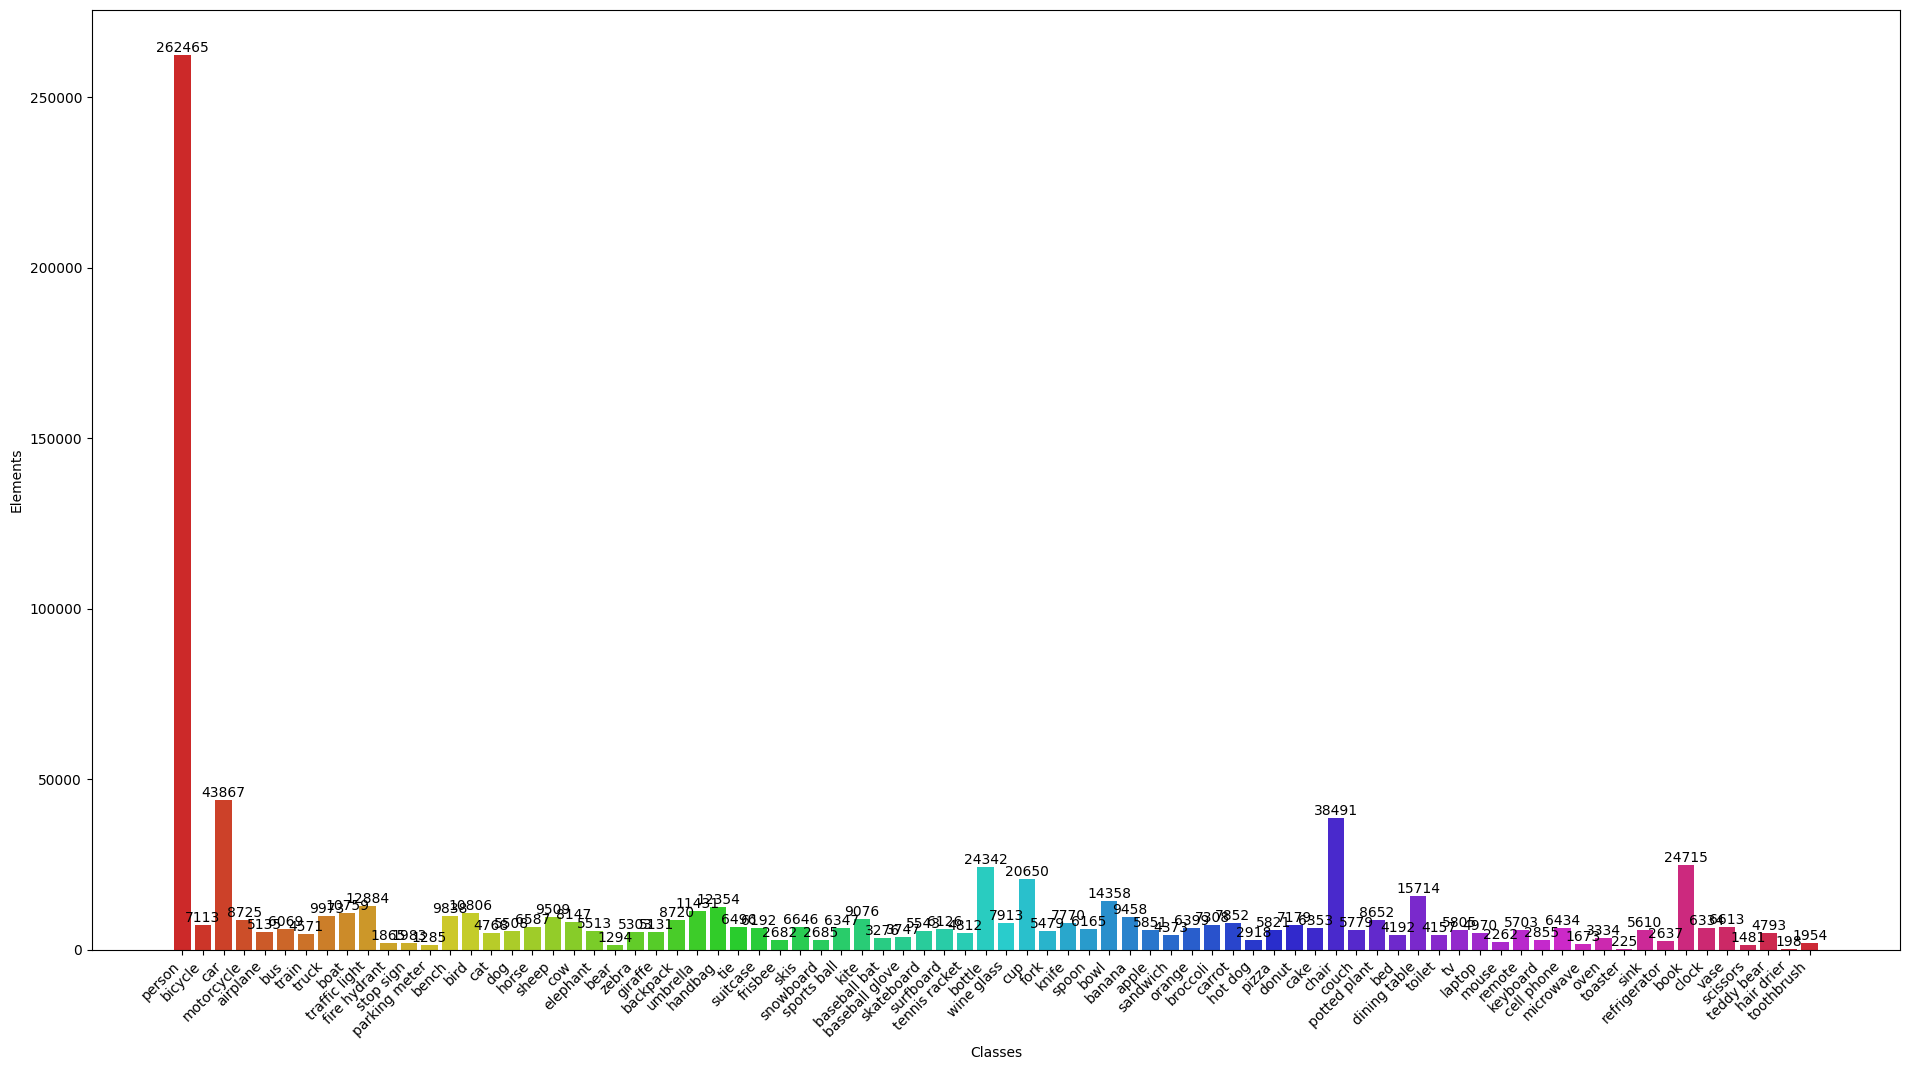

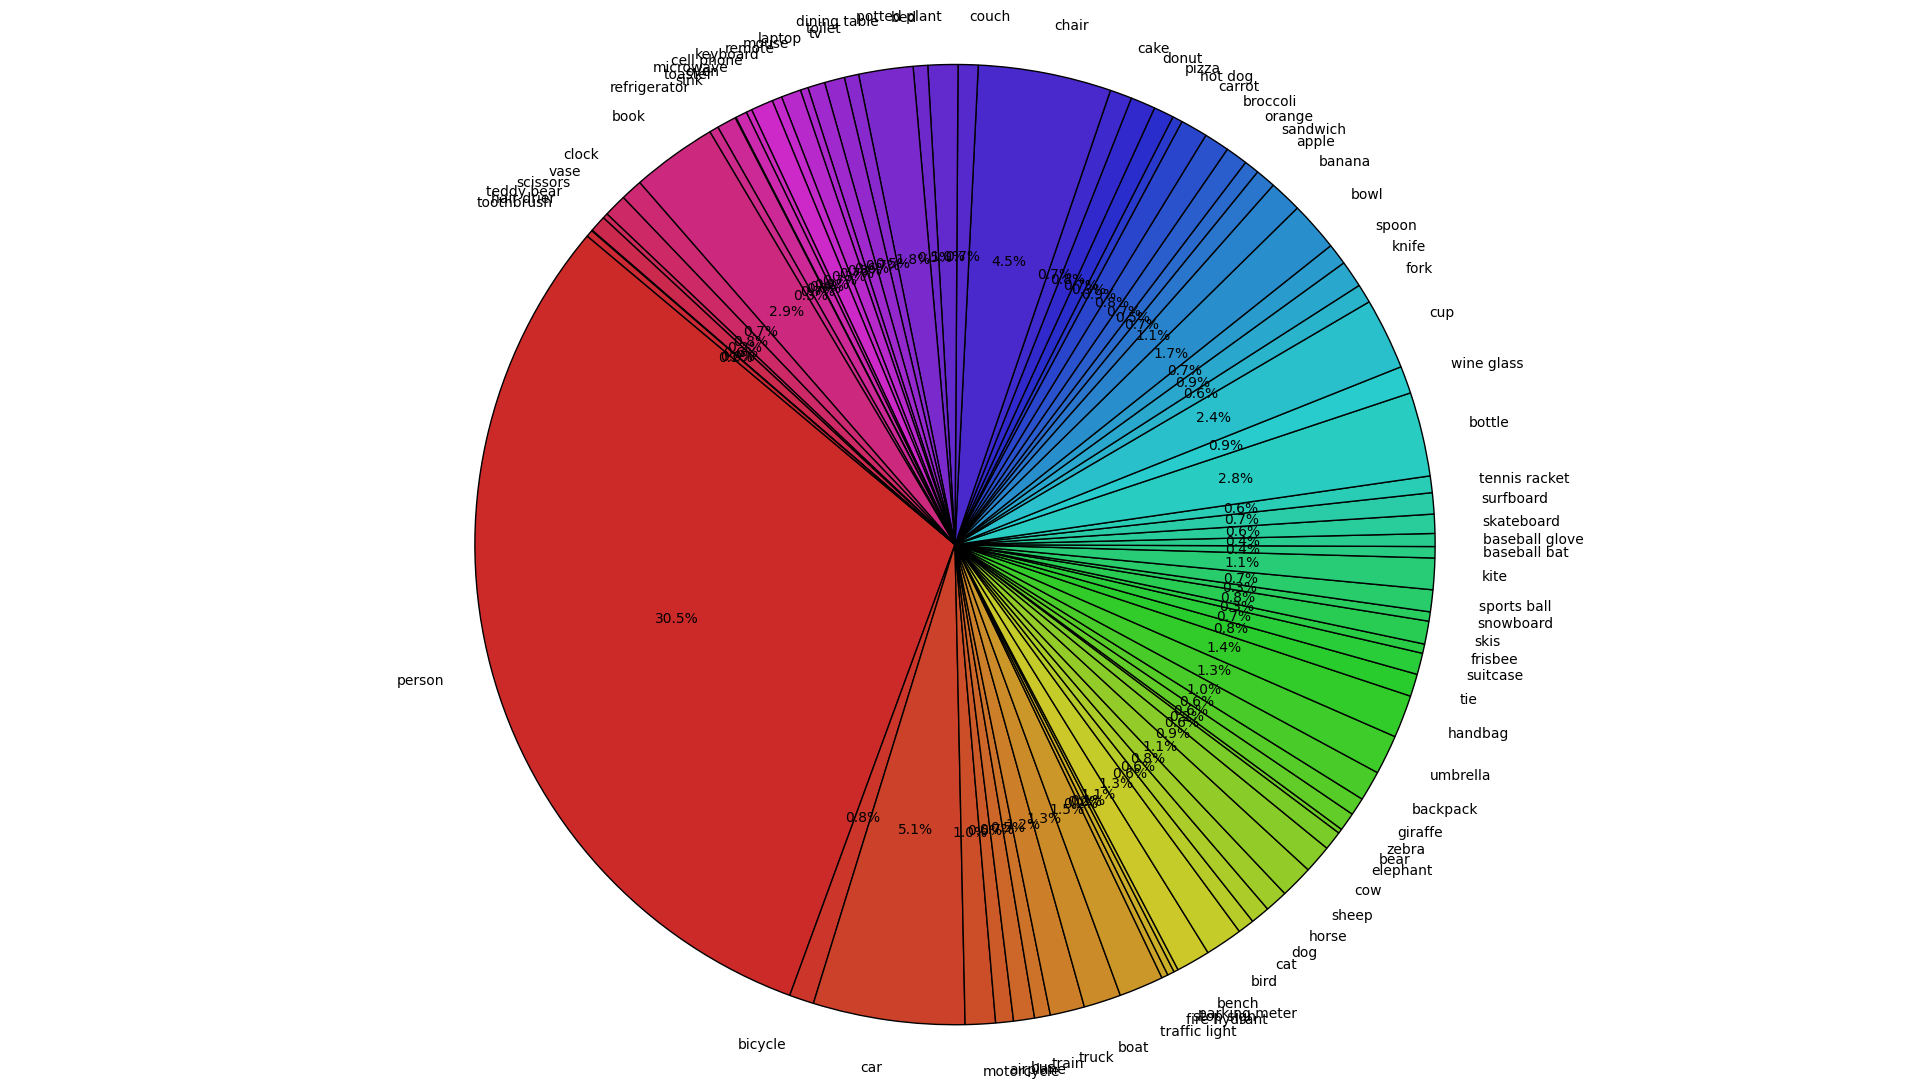

In [14]:
plt.figure(figsize=(19.2, 10.8))
barplot = plt.bar(range(len(categories)), elements_per_class_trainset, color=colors)
plt.bar_label(barplot, elements_per_class_trainset)
plt.xlabel('Classes')
plt.ylabel('Elements')
plt.xticks(range(len(categories)), categories, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_classes_distribution"), pad_inches=0.)
plt.show()

plt.figure(figsize=(19.2, 10.8))
plt.pie(elements_per_class_trainset, labels=categories.keys(), autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{dataset_name}_pie_classes_distribution"), pad_inches=0.)
plt.show()